# Hari 1 — Exploratory Data Analysis (EDA)
**Project:** Indonesian Toxic Comment Classifier  
**Tujuan hari ini:** Kenali dataset sebelum menyentuh model. EDA yang baik mencegah kesalahan fatal di tahap modeling.

---
### File yang tersedia
| File | Isi |
|------|-----|
| `data.csv` | Dataset utama — 13.169 tweets dengan label |
| `new_kamusalay.csv` | Kamus slang/typo → kata formal (15.167 entri) |
| `abusive.csv` | Daftar 125 kata kasar |

Untuk hari ini kita fokus pada `data.csv`.

## 0. Import Libraries
Boilerplate — tidak perlu dihafal, tapi pahami *mengapa* masing-masing diimport.

In [1]:
import pandas as pd               # manipulasi data tabular
import matplotlib.pyplot as plt   # visualisasi
import seaborn as sns             # visualisasi statistik (lebih rapi dari matplotlib)

# agar plot muncul langsung di notebook
%matplotlib inline

---
## 1. Load Dataset

**Konteks:** Dataset ini berisi karakter non-UTF-8 (emoji Twitter lama), jadi kita perlu menentukan encoding secara eksplisit.

**Instruksi:**  
- Gunakan `pd.read_csv()` untuk membaca file `../data/data.csv`  
- Tambahkan parameter `encoding='latin-1'`  
- Simpan ke variabel bernama `df`  
- Tampilkan 3 baris pertama dengan `.head(3)`

In [2]:
# TODO: load dataset
df = pd.read_csv("../data/data.csv", encoding='latin-1')

# TODO: tampilkan 3 baris pertama
print(df.head(3))

                                               Tweet  HS  Abusive  \
0  - disaat semua cowok berusaha melacak perhatia...   1        1   
1  RT USER: USER siapa yang telat ngasih tau elu?...   0        1   
2  41. Kadang aku berfikir, kenapa aku tetap perc...   0        0   

   HS_Individual  HS_Group  HS_Religion  HS_Race  HS_Physical  HS_Gender  \
0              1         0            0        0            0          0   
1              0         0            0        0            0          0   
2              0         0            0        0            0          0   

   HS_Other  HS_Weak  HS_Moderate  HS_Strong  
0         1        1            0          0  
1         0        0            0          0  
2         0        0            0          0  


---
## 2. Ukuran & Struktur Data

**Konteks:** Langkah pertama EDA selalu: *seberapa besar data ini, dan kolom apa saja yang ada?*

**Instruksi:**  
- Tampilkan jumlah baris dan kolom dengan `.shape`  
- Tampilkan nama semua kolom dengan `.columns`  
- Tampilkan tipe data tiap kolom dan jumlah non-null dengan `.info()`

In [36]:
# TODO: tampilkan shape
print("Shape:", df.shape )

# TODO: tampilkan nama kolom
print("Columns:", df.columns )

# TODO: tampilkan info lengkap
df.info()

Shape: (13044, 14)
Columns: Index(['Tweet', 'HS', 'Abusive', 'HS_Individual', 'HS_Group', 'HS_Religion',
       'HS_Race', 'HS_Physical', 'HS_Gender', 'HS_Other', 'HS_Weak',
       'HS_Moderate', 'HS_Strong', 'tweet_length'],
      dtype='str')
<class 'pandas.DataFrame'>
Index: 13044 entries, 0 to 13168
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Tweet          13044 non-null  str  
 1   HS             13044 non-null  int64
 2   Abusive        13044 non-null  int64
 3   HS_Individual  13044 non-null  int64
 4   HS_Group       13044 non-null  int64
 5   HS_Religion    13044 non-null  int64
 6   HS_Race        13044 non-null  int64
 7   HS_Physical    13044 non-null  int64
 8   HS_Gender      13044 non-null  int64
 9   HS_Other       13044 non-null  int64
 10  HS_Weak        13044 non-null  int64
 11  HS_Moderate    13044 non-null  int64
 12  HS_Strong      13044 non-null  int64
 13  tweet_length   13044 non-nu

In [37]:
# TODO: hitung distribusi label HS
print("Jumlah:")
print(df.value_counts('HS'))

print("\nPersentase:")
print(df['HS'].value_counts(normalize=True))

Jumlah:
HS
0    7526
1    5518
Name: count, dtype: int64

Persentase:
HS
0    0.57697
1    0.42303
Name: proportion, dtype: float64


---
## 3. Cek Missing Values

**Konteks:** Missing values bisa menyebabkan error saat training. Kita perlu tahu apakah ada sebelum lanjut.

**Instruksi:**  
- Gunakan `.isnull().sum()` untuk menghitung jumlah nilai kosong per kolom  
- Simpan ke variabel `missing`, lalu print

In [4]:
# TODO: hitung missing values per kolom
missing = df.isnull().sum()
print(missing)

Tweet            0
HS               0
Abusive          0
HS_Individual    0
HS_Group         0
HS_Religion      0
HS_Race          0
HS_Physical      0
HS_Gender        0
HS_Other         0
HS_Weak          0
HS_Moderate      0
HS_Strong        0
dtype: int64


---
## 4. Cek Duplikat

**Konteks:** Tweet yang sama muncul dua kali bisa membuat model 'menghafal' data tersebut (overfitting). Kita deteksi dulu, baru hapus.

**Instruksi:**  
- Hitung jumlah baris duplikat dengan `.duplicated().sum()`  
- Jika ada duplikat, hapus dengan `.drop_duplicates()` dan simpan kembali ke `df`  
- Print jumlah baris sebelum dan sesudah

In [5]:
print("Baris sebelum:", len(df))

# TODO: hitung duplikat
jumlah_duplikat = df.duplicated().sum()
print("Jumlah duplikat:", jumlah_duplikat)

# TODO: hapus duplikat dan simpan ke df
df = df.drop_duplicates()

print("Baris sesudah:", len(df))

Baris sebelum: 13169
Jumlah duplikat: 125
Baris sesudah: 13044


---
## 5. Distribusi Label Target

**Konteks:** Kita akan menggunakan kolom `HS` (hate speech) sebagai label target.
- `1` = tweet mengandung hate speech  
- `0` = tidak  

Distribusi label penting untuk diketahui — kalau sangat tidak balance (misal 95% vs 5%), model bisa bias.

**Instruksi:**  
- Hitung jumlah tiap nilai di kolom `HS` dengan `.value_counts()`  
- Hitung juga persentasenya dengan `.value_counts(normalize=True)`  
- Buat bar chart dari `.value_counts()` menggunakan `.plot(kind='bar')`

In [6]:
# TODO: hitung distribusi label HS
print("Jumlah:")
print(df.value_counts('HS'))

print("\nPersentase:")
print(df.value_counts(normalize=True))

Jumlah:
HS
0    7526
1    5518
Name: count, dtype: int64

Persentase:
Tweet                                                                                                                                                                                                                                                           HS  Abusive  HS_Individual  HS_Group  HS_Religion  HS_Race  HS_Physical  HS_Gender  HS_Other  HS_Weak  HS_Moderate  HS_Strong
- disaat semua cowok berusaha melacak perhatian gue. loe lantas remehkan perhatian yg gue kasih khusus ke elo. basic elo cowok bego ! ! !'                                                                                                                      1   1        1              0         0            0        0            0          1         1        0            0            0.000077
RT USER: USER siapa yang telat ngasih tau elu?edan sarap gue bergaul dengan cigax jifla calis sama siapa noh licew juga'                                  

(array([0, 1]), [Text(0, 0, 'Non-Toxic'), Text(1, 0, 'Toxic')])

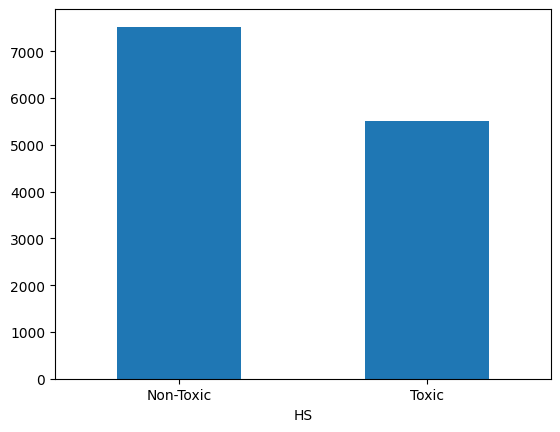

In [ ]:
# TODO: buat bar chart distribusi label HS
# Tips: gunakan plt.title(), plt.xlabel(), plt.ylabel() untuk label yang informatif

# kalau mau label x-axis lebih jelas (bukan 0/1)
df['HS'].value_counts().rename(index={0: 'Non-Toxic', 1: 'Toxic'}).plot(kind='bar')
plt.xticks(rotation=0)  # biar label tidak miring

---
## 6. Eksplorasi Kolom Tweet

**Konteks:** Sebelum preprocessing teks, kita perlu tahu karakteristik tweet — seberapa panjang, apakah ada yang kosong.

**Instruksi:**  
- Buat kolom baru bernama `tweet_length` yang berisi panjang karakter tiap tweet  
  *(Hint: gunakan `.str.len()`)*  
- Tampilkan statistik deskriptif kolom itu dengan `.describe()`  
- Buat histogram distribusi panjang tweet dengan `plt.hist()`

In [13]:
# TODO: buat kolom tweet_length
df['tweet_length'] = df['Tweet'].str.len()

# TODO: tampilkan statistik deskriptif
print(df['tweet_length'].describe())

count    13044.000000
mean       114.124348
std         69.101629
min          4.000000
25%         59.000000
50%        100.000000
75%        152.000000
max        561.000000
Name: tweet_length, dtype: float64


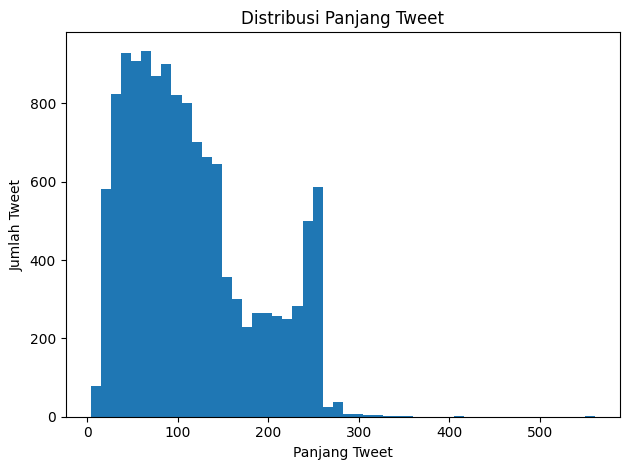

In [17]:
# TODO: histogram panjang tweet
# Tips: plt.hist(data, bins=...) — coba bins=50

data = (df['tweet_length'])
plt.hist(data, bins=50)
plt.title('Distribusi Panjang Tweet')
plt.xlabel('Panjang Tweet')
plt.ylabel('Jumlah Tweet')
plt.tight_layout()
plt.show()

---
## 7. Perbandingan Panjang Tweet: Toxic vs Non-Toxic

**Konteks:** Apakah tweet toxic cenderung lebih panjang atau pendek? Ini insight yang menarik dan bisa jadi bahan cerita di portfolio.

**Instruksi:**  
- Filter `df` menjadi dua subset: `df_toxic` (HS==1) dan `df_clean` (HS==0)  
- Buat dua histogram di satu plot menggunakan `plt.hist()` dua kali dengan `alpha=0.6` agar transparan  
- Tambahkan `label=` di tiap histogram, lalu panggil `plt.legend()`

In [19]:
# TODO: filter toxic dan non-toxic
df_toxic = df[df['HS'] == 1]
df_clean = df[df['HS'] == 0]

print(f"Jumlah toxic: {len(df_toxic)}, non-toxic: {len(df_clean)}")

Jumlah toxic: 5518, non-toxic: 7526


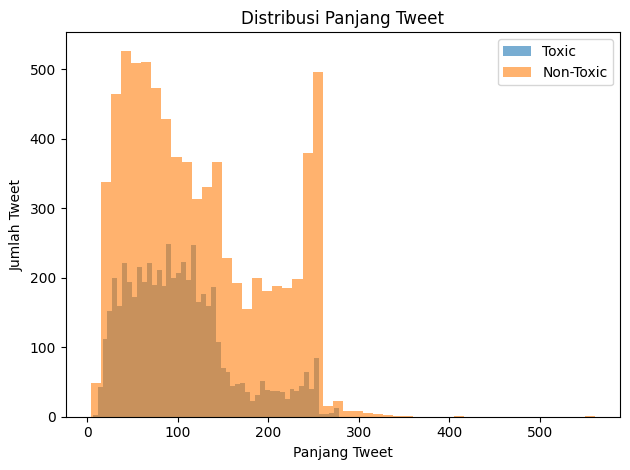

In [32]:
# TODO: overlay histogram toxic vs non-toxic
plt.hist(
    df_toxic['tweet_length'],
    bins=50,
    alpha=0.6,
    label='Toxic'
)

plt.hist(
    df_clean['tweet_length'],
    bins=50,
    alpha=0.6,
    label='Non-Toxic'
)

plt.title('Distribusi Panjang Tweet')
plt.xlabel('Panjang Tweet')
plt.ylabel('Jumlah Tweet')
plt.legend()

plt.tight_layout()
plt.show()

---
## 8. Lihat Contoh Tweet

**Konteks:** Selalu baca datamu secara manual. Insight terbaik sering datang dari membaca 10–20 sampel — bukan dari statistik.

**Instruksi:**  
- Ambil 5 tweet acak dari `df_toxic` menggunakan `.sample(5)`  
- Tampilkan hanya kolom `Tweet` dan `HS`  
- Lakukan hal yang sama untuk `df_clean`

In [35]:
# TODO: tampilkan 5 sampel tweet toxic
print("=== TOXIC ===")
print(df_toxic[['Tweet', 'HS']].sample(10))

print("\n=== NON-TOXIC ===")
# TODO: tampilkan 5 sampel tweet non-toxic
print(df_clean[['Tweet', 'HS']].sample(10))


=== TOXIC ===
                                                   Tweet  HS
3595   USER Gak cucok antara antara langit dan bumi k...   1
2323    mau cerita. laki2 emang brengsek ya. dasar cupu'   1
1786   ini semua berawal dari AHOK JAMBAN yg dibela a...   1
13024  USER Pak USER walau belum semua tahu Quran kit...   1
2882   #SidangAhok smg sipenista agama n ateknya mati...   1
12685  Ketemu klien, orang batak, dia ngegas gua ikut...   1
5483   USER Muhammad menurut Quran manusia BEJAD, san...   1
1624   kita hanya butuh presiden Baru Yang Tegas Gany...   1
7275   USER USER Azu tenan soh orang2 kek.gini nih......   1
12933  RT USER: USER Heran juga saya, setan iblis pad...   1

=== NON-TOXIC ===
                                                   Tweet  HS
7359   "Tidak peduli sesulit apa aku menghadapi sesua...   0
11606                              Atas dasar hukum apa?   0
12994               USER Bokong cekcih \xf0\x9f\x98\x82'   0
6724   USER Duh kok kesannya insensitive gt yaaa sis

---
## 9. Ringkasan Temuan

Isi cell markdown ini setelah kamu selesai mengerjakan semua cell di atas.  
Jawab pertanyaan berikut dengan kata-katamu sendiri:

1. Berapa jumlah data yang tersisa setelah drop duplikat?
2. Apakah distribusi label balance? Apa implikasinya?
3. Berapa rata-rata panjang tweet?
4. Dari contoh yang kamu baca, pola apa yang kamu lihat dari tweet toxic?
5. Ada hal menarik lain yang kamu temukan?

*(Tulis jawabanmu di sini)*

1. 13044 baris
2. cukup balance, model jadi menerima kedua label dengan baik, mengurangi potensi bias
3. 114 karakter
4. tweet toxic cenderung lebih pendek (to the point). itu saja insight yang kudapat dari histogram, aku kurang bisa menyerap informasi dari histogram
5. setelah beberapa kali ambil sampel, aku melihat ada data yang Hate speech, tapi masuk di df_clean, (label HSnya 0)

---
## ✅ Checklist Hari 1
Sebelum lanjut ke Hari 2, pastikan kamu sudah:
- [ ] Dataset berhasil di-load
- [ ] Tahu jumlah baris, kolom, dan tipe data
- [ ] Tidak ada missing value yang tersembunyi
- [ ] Duplikat sudah di-drop
- [ ] Paham distribusi label HS
- [ ] Sudah membaca minimal 10 sampel tweet secara manual
- [ ] Mengisi ringkasan temuan di Section 9